# 📘 Deep Learning Text Generation Learning Project
## Text Generation using **Vanilla RNN, LSTM, and GRU**

This notebook is built for **students and beginners** to understand how sequence models learn:
- grammar
- sentence flow
- contextual dependencies
- next-word prediction
- text generation

🎯 **Goal:** Compare **Simple RNN vs LSTM vs GRU** on the same text corpus and understand why gated architectures perform better.

# 🧠 Problem Statement
Design and implement a DL model capable of learning the underlying structure, grammar, and contextual dependencies of a given text corpus to generate coherent and meaningful text sequences using:

1. **Vanilla RNN**
2. **LSTM**
3. **GRU**

Then compare:
- training loss
- generated text quality
- memory handling
- long-term dependency learning

In [7]:
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, GRU, Dense
import numpy as np
import matplotlib.pyplot as plt
print("TensorFlow:", tf.__version__)

TensorFlow: 2.20.0


# 📥 Load Text Corpus
We use a **small built-in sample corpus** so students can run this quickly.
You can later replace it with:
- Shakespeare text
- song lyrics
- chatbot data
- story paragraphs
- custom PDF extracted text

In [8]:
corpus = '''
deep learning is transforming artificial intelligence
recurrent neural networks are useful for sequential data
lstm helps remember long term dependencies
gru is faster and simpler than lstm
text generation models predict the next word
deep learning models can generate meaningful sentences
'''
print(corpus)


deep learning is transforming artificial intelligence
recurrent neural networks are useful for sequential data
lstm helps remember long term dependencies
gru is faster and simpler than lstm
text generation models predict the next word
deep learning models can generate meaningful sentences



# 🔤 Tokenization & Sequence Creation
We convert text into integer tokens and create **n-gram style sequences**
for next-word prediction.

In [9]:
tokenizer = Tokenizer()
tokenizer.fit_on_texts([corpus])

total_words = len(tokenizer.word_index) + 1
print("Vocabulary size:", total_words)

input_sequences = []
for line in corpus.split('\n'):
    token_list = tokenizer.texts_to_sequences([line])[0]
    for i in range(1, len(token_list)):
        n_gram_seq = token_list[:i+1]
        input_sequences.append(n_gram_seq)

max_len = max(len(seq) for seq in input_sequences)
input_sequences = pad_sequences(input_sequences, maxlen=max_len, padding='pre')

X = input_sequences[:, :-1]
y = input_sequences[:, -1]

print("X shape:", X.shape)
print("y shape:", y.shape)

Vocabulary size: 37
X shape: (35, 7)
y shape: (35,)


# 🧠 Model 1: Vanilla RNN
This is the baseline sequential model.
It struggles with long-term dependencies because of vanishing gradients.

In [11]:
rnn_model = Sequential([
    Embedding(total_words, 32, input_length=max_len-1),
    SimpleRNN(64),
    Dense(total_words, activation='softmax')
])

rnn_model.compile(loss='sparse_categorical_crossentropy',
                  optimizer='adam',
                  metrics=['accuracy'])

rnn_history = rnn_model.fit(X, y, epochs=100, verbose=0)
print("Vanilla RNN training completed")

Vanilla RNN training completed


# 🔒 Model 2: LSTM
LSTM uses **input, forget, and output gates**
to preserve long-term memory.

In [12]:
lstm_model = Sequential([
    Embedding(total_words, 32, input_length=max_len-1),
    LSTM(64),
    Dense(total_words, activation='softmax')
])

lstm_model.compile(loss='sparse_categorical_crossentropy',
                   optimizer='adam',
                   metrics=['accuracy'])

lstm_history = lstm_model.fit(X, y, epochs=100, verbose=0)
print("LSTM training completed")

LSTM training completed


# ⚡ Model 3: GRU
GRU uses **reset + update gates**.
It is computationally faster than LSTM and often gives similar results.

In [13]:
gru_model = Sequential([
    Embedding(total_words, 32, input_length=max_len-1),
    GRU(64),
    Dense(total_words, activation='softmax')
])

gru_model.compile(loss='sparse_categorical_crossentropy',
                  optimizer='adam',
                  metrics=['accuracy'])

gru_history = gru_model.fit(X, y, epochs=100, verbose=0)
print("GRU training completed")

GRU training completed


## 📉 Compare Training Loss

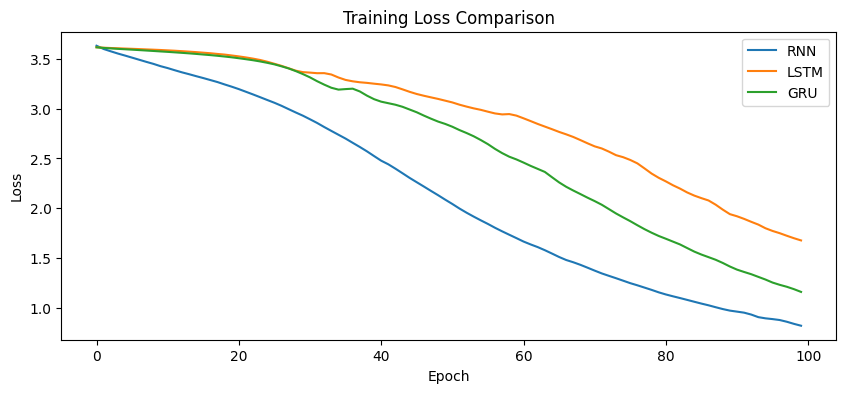

In [14]:
plt.figure(figsize=(10,4))
plt.plot(rnn_history.history['loss'], label='RNN')
plt.plot(lstm_history.history['loss'], label='LSTM')
plt.plot(gru_history.history['loss'], label='GRU')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss Comparison")
plt.legend()
plt.show()

# ✍️ Text Generation Function
This function predicts the next word repeatedly to generate a sentence.

In [15]:
def generate_text(model, seed_text, next_words=5):
    for _ in range(next_words):
        token_list = tokenizer.texts_to_sequences([seed_text])[0]
        token_list = pad_sequences([token_list], maxlen=max_len-1, padding='pre')
        predicted = np.argmax(model.predict(token_list, verbose=0), axis=-1)[0]

        output_word = ""
        for word, index in tokenizer.word_index.items():
            if index == predicted:
                output_word = word
                break
        seed_text += " " + output_word
    return seed_text

## 🧪 Generate Text Samples

In [16]:
print("RNN :", generate_text(rnn_model, "deep learning", 5))
print("LSTM:", generate_text(lstm_model, "deep learning", 5))
print("GRU :", generate_text(gru_model, "deep learning", 5))

RNN : deep learning models can generate meaningful sentences
LSTM: deep learning models transforming artificial intelligence intelligence
GRU : deep learning models can generate meaningful sentences


# 📚 Student Learning Tasks
### ✅ Beginner Tasks
1. Replace corpus with your own paragraph
2. Increase embedding dimension
3. Increase epochs to 200
4. Change hidden units 64 → 128
5. Generate 10 words instead of 5

## ✅ Solutions to Beginner Tasks

### Task 1: Replace corpus with your own paragraph

In [17]:
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, GRU, Dense
import numpy as np
import matplotlib.pyplot as plt

corpus_new = '''
the quick brown fox jumps over the lazy dog
languages are fascinating and complex systems
natural language processing helps machines understand human speech
transformers have revolutionized sequence modeling tasks
large language models can generate coherent and creative text
'''
print("New Corpus:")
print(corpus_new)

# Re-tokenize and create sequences for the new corpus
tokenizer_new = Tokenizer()
tokenizer_new.fit_on_texts([corpus_new])

total_words_new = len(tokenizer_new.word_index) + 1
print("\nNew Vocabulary size:", total_words_new)

input_sequences_new = []
for line in corpus_new.split('\n'):
    token_list_new = tokenizer_new.texts_to_sequences([line])[0]
    for i in range(1, len(token_list_new)):
        n_gram_seq_new = token_list_new[:i+1]
        input_sequences_new.append(n_gram_seq_new)

max_len_new = max(len(seq) for seq in input_sequences_new)
input_sequences_new = pad_sequences(input_sequences_new, maxlen=max_len_new, padding='pre')

X_new = input_sequences_new[:, :-1]
y_new = input_sequences_new[:, -1]

print("\nX_new shape:", X_new.shape)
print("y_new shape:", y_new.shape)

New Corpus:

the quick brown fox jumps over the lazy dog
languages are fascinating and complex systems
natural language processing helps machines understand human speech
transformers have revolutionized sequence modeling tasks
large language models can generate coherent and creative text


New Vocabulary size: 36

X_new shape: (33, 8)
y_new shape: (33,)


### Tasks 2, 3 & 4: Increase embedding dimension, Increase epochs to 200, Change hidden units 64 → 128

Now we will retrain all three models (RNN, LSTM, GRU) using the new corpus (`corpus_new`), with an embedding dimension of `64`, `128` hidden units, and `200` epochs.

In [18]:
embedding_dim_v2 = 64
hidden_units_v2 = 128
epochs_v2 = 200

# Model 1: Vanilla RNN with updated parameters
rnn_model_v2 = Sequential([
    Embedding(total_words_new, embedding_dim_v2, input_length=max_len_new-1),
    SimpleRNN(hidden_units_v2),
    Dense(total_words_new, activation='softmax')
])

rnn_model_v2.compile(loss='sparse_categorical_crossentropy',
                       optimizer='adam',
                       metrics=['accuracy'])

rnn_history_v2 = rnn_model_v2.fit(X_new, y_new, epochs=epochs_v2, verbose=0)
print("Vanilla RNN (v2) training completed")

# Model 2: LSTM with updated parameters
lstm_model_v2 = Sequential([
    Embedding(total_words_new, embedding_dim_v2, input_length=max_len_new-1),
    LSTM(hidden_units_v2),
    Dense(total_words_new, activation='softmax')
])

lstm_model_v2.compile(loss='sparse_categorical_crossentropy',
                        optimizer='adam',
                        metrics=['accuracy'])

lstm_history_v2 = lstm_model_v2.fit(X_new, y_new, epochs=epochs_v2, verbose=0)
print("LSTM (v2) training completed")

# Model 3: GRU with updated parameters
gru_model_v2 = Sequential([
    Embedding(total_words_new, embedding_dim_v2, input_length=max_len_new-1),
    GRU(hidden_units_v2),
    Dense(total_words_new, activation='softmax')
])

gru_model_v2.compile(loss='sparse_categorical_crossentropy',
                       optimizer='adam',
                       metrics=['accuracy'])

gru_history_v2 = gru_model_v2.fit(X_new, y_new, epochs=epochs_v2, verbose=0)
print("GRU (v2) training completed")

Vanilla RNN (v2) training completed
LSTM (v2) training completed
GRU (v2) training completed


### Compare Training Loss (v2 Models)

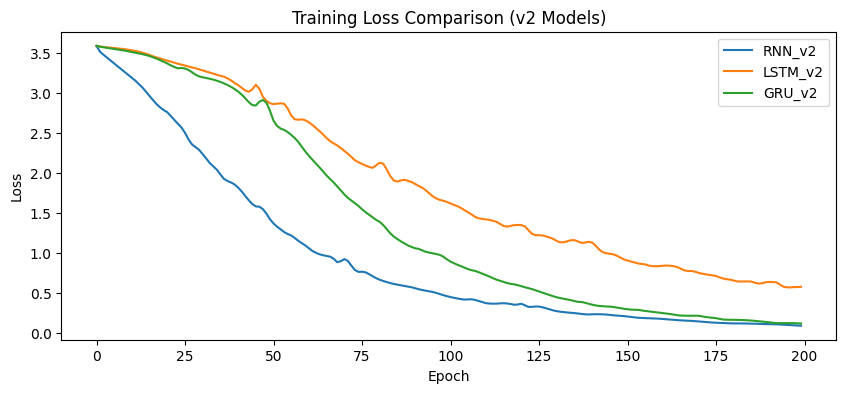

In [19]:
plt.figure(figsize=(10,4))
plt.plot(rnn_history_v2.history['loss'], label='RNN_v2')
plt.plot(lstm_history_v2.history['loss'], label='LSTM_v2')
plt.plot(gru_history_v2.history['loss'], label='GRU_v2')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss Comparison (v2 Models)")
plt.legend()
plt.show()

### Task 5: Generate 10 words instead of 5

Now, let's generate longer sequences (10 words) using the updated models and the new corpus. Note that the `generate_text` function uses the `tokenizer` and `max_len` from the initial setup, so we need a slightly modified version or ensure `tokenizer_new` and `max_len_new` are used.

In [20]:
def generate_text_v2(model, seed_text, next_words=10):
    for _ in range(next_words):
        token_list = tokenizer_new.texts_to_sequences([seed_text])[0]
        token_list = pad_sequences([token_list], maxlen=max_len_new-1, padding='pre')
        predicted_index = np.argmax(model.predict(token_list, verbose=0), axis=-1)[0]

        output_word = ""
        for word, index in tokenizer_new.word_index.items():
            if index == predicted_index:
                output_word = word
                break
        if output_word == "": # Handle cases where a word might not be found (unlikely with this setup)
            break
        seed_text += " " + output_word
    return seed_text

print("RNN (v2):", generate_text_v2(rnn_model_v2, "the quick", 10))
print("LSTM (v2):", generate_text_v2(lstm_model_v2, "languages are", 10))
print("GRU (v2) :", generate_text_v2(gru_model_v2, "natural language", 10))

RNN (v2): the quick brown fox jumps over the lazy dog text jumps over
LSTM (v2): languages are fascinating and complex systems systems systems text text text dog
GRU (v2) : natural language processing helps machines understand human speech speech speech speech speech


# ✅ Conclusion
- **Vanilla RNN** learns short patterns but struggles with memory
- **LSTM** captures long-range grammar dependencies better
- **GRU** gives similar performance with fewer gates and faster training
- This notebook helps students understand **sequence modeling mathematically and practically**